<a href="https://colab.research.google.com/github/umanshibakshi/Deep-Learning/blob/main/CNN_Vertical_Edge_Detection_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Setup: Imports and Data Definition
This section imports necessary libraries (NumPy, Matplotlib) and defines the input image and the vertical edge detection filter. The image has a clear vertical edge, and the filter is designed to detect such features.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Define input image (6x6 matrix)
image = np.array([
    [10, 10, 10,  0,  0,  0],
    [10, 10, 10,  0,  0,  0],
    [10, 10, 10,  0,  0,  0],
    [10, 10, 10,  0,  0,  0],
    [10, 10, 10,  0,  0,  0],
    [10, 10, 10,  0,  0,  0]
])

# Define vertical edge filter (3x3 matrix)
filter = np.array([
    [1,  0,  -1],
    [1,  0, -1],
    [1,  0, -1]
])

print("Input Image (6x6):")
display(image)
print("\nFilter (3x3) for vertical edge detection:")
display(filter)

Input Image (6x6):


array([[10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0]])


Filter (3x3) for vertical edge detection:


array([[ 1,  0, -1],
       [ 1,  0, -1],
       [ 1,  0, -1]])

### 2. Convolution Computation
This cell performs the 2D convolution operation. It slides the filter over the input image, calculating the dot product at each position to produce an output feature map. This specific filter will highlight vertical edges by producing a high value when a transition from high to low intensity occurs from left to right.

In [2]:
# Calculate output dimensions for 'valid' padding (no padding, stride 1)
out_h = image.shape[0] - filter.shape[0] + 1
out_w = image.shape[1] - filter.shape[1] + 1
output = np.zeros((out_h, out_w), dtype=int)

# Perform 2D convolution from scratch
for r in range(out_h):
    for c in range(out_w):
        receptive_field = image[r:r + filter.shape[0], c:c + filter.shape[1]]
        output[r, c] = np.sum(receptive_field * filter)

print("Output Feature Map (4x4) after convolution:")
display(output)

Output Feature Map (4x4) after convolution:


array([[ 0, 30, 30,  0],
       [ 0, 30, 30,  0],
       [ 0, 30, 30,  0],
       [ 0, 30, 30,  0]])

### 3. Visualization of Matrices with Proportional Sizes
This final cell visualizes the input image, the filter, and the resulting output feature map. It uses `matplotlib.gridspec` to display the subplots with widths proportional to the actual matrix sizes, making the visual representation reflect their dimensions more accurately. Numerical values are overlaid for clarity, with text color adjusted for contrast.

/tmp/ipykernel_1287/1710226107.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


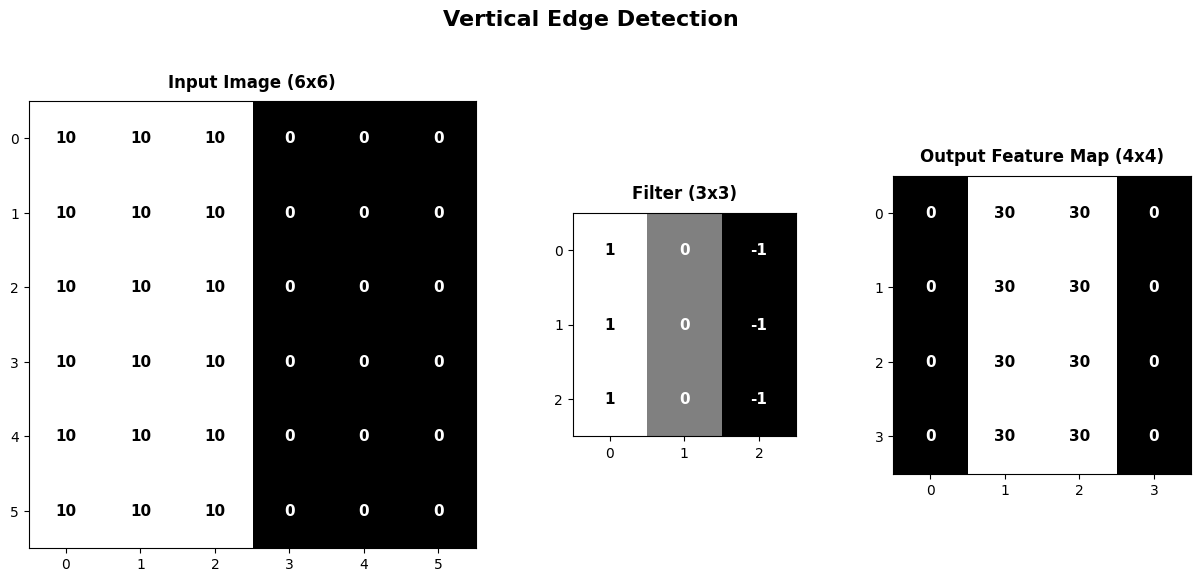

In [3]:
fig = plt.figure(figsize=(15, 6)) # Overall figure size
gs = GridSpec(1, 3, width_ratios=[image.shape[1], filter.shape[1], output.shape[1]], wspace=0.3)

# Global title for the entire figure
fig.suptitle("Vertical Edge Detection", fontsize=16, fontweight="bold", y=1.02)

panels = [
    (image, f"Input Image ({image.shape[0]}x{image.shape[1]})"),
    (filter, f"Filter ({filter.shape[0]}x{filter.shape[1]})"),
    (output, f"Output Feature Map ({output.shape[0]}x{output.shape[1]})")
]

for i, (mat, title) in enumerate(panels):
    ax = fig.add_subplot(gs[i])

    # Display matrix in grayscale with values scaled to min/max of current matrix
    ax.imshow(mat, cmap="gray", vmin=mat.min(), vmax=mat.max())
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

    rows, cols = mat.shape
    # Determine midpoint for text color contrast
    midpoint = (mat.min() + mat.max()) / 2

    # Overlay numerical values on each cell
    for r in range(rows):
        for c in range(cols):
            val = mat[r, c]
            text_color = "white" if val <= midpoint else "black"
            ax.text(c, r, str(val), ha="center", va="center",
                    fontsize=11, fontweight="bold", color=text_color)

    # Set ticks to correspond to matrix indices
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))

plt.show()